In [ ]:
# Import all the libraries
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import numpy as np
import pandas as pd
import geopandas as gpd
import cv2
import os
import albumentations as A
from shapely.geometry import box
from rasterio import features

In [ ]:
class CurbDataset(Dataset):
    def __init__(self,
                 csv_path,          # Path to CSV file (Excel)
                 images_dir,        # Folder with the images on JPGs format
                 shapefile_path,    # Path to the master .shp file
                 transform=None,    # Albumentations (Augmentations)
                 pixels_per_unit=4, # 4 pixels = 1 foot (CAD settings)
                 img_size=1024):    # 1024x1024 resolution

        # Load CSV file
        print("Loading CSV file...")
        self.df = pd.read_csv(csv_path)

        # Clean the data by dropping empty rows at the bottom of the file and converting the first column to string
        self.df = self.df.dropna(subset=['image_name'])
        self.df['image_name'] = self.df['image_name'].astype(str)
        print(f"CSV file with world coordinates loaded. We are working with {len(self.df)} images.")

        self.images_dir = images_dir
        self.transform = transform
        self.pixels_per_unit = pixels_per_unit
        self.img_size = img_size

        # Load shapefile once so it avoids to load it all the time
        print("Loading Master Shapefile...")
        self.gdf = gpd.read_file(shapefile_path)
        self.sindex = self.gdf.sindex
        print(f"Shapefile loaded and indexed.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        ######################
        # Get Image Coordinates Info from Excel
        ######################
        row = self.df.iloc[idx]
        img_name = row['image_name']  # First column name in the csv file
        img_name += ".jpg"
        origin_x = row['x_top_left'] # Second column name in the csv file
        origin_y = row['y_top_left'] # Third column name in the csv file

        ######################
        # Load the Image (JPG)
        ######################
        img_path = os.path.join(self.images_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

        ######################
        # Calculate the real size(world) for this image
        # We need to know what area of the real size this 1024x1024 image covers.
        # Image Width (ft) = 1024 pixels / 4 pixels per ft = 256 ft
        ######################
        world_width = self.img_size / self.pixels_per_unit

        # Define the 4 corners (MinX, MinY, MaxX, MaxY)
        # In AutoCAD the y axis goes up when we move up which it is the opposite from python
        # Origin_Y is the TOP. MinY is Origin_Y - 256
        window_geom = box(origin_x, origin_y - world_width,
                          origin_x + world_width, origin_y)

        ######################
        # Find Intersecting Lines by searching the spatial index for lines that fit in the image
        ######################
        possible_matches_index = list(self.sindex.intersection(window_geom.bounds))
        possible_matches = self.gdf.iloc[possible_matches_index]
        precise_matches = possible_matches[possible_matches.intersects(window_geom)]

        ######################
        # Create the Mask
        # We should start with a blank black mask
        ######################
        mask = np.zeros((self.img_size, self.img_size), dtype=np.uint8)

        if not precise_matches.empty:
            # We clip the lines to fit inside the box
            clipped_lines = precise_matches.intersection(window_geom)

            # Now we must transform World Coordinates to Pixel Coordinates
            # Shift everything so Top-Left is (0,0)
            # We shift X by -origin_x
            # We shift Y by -origin_y
            shapes_centered = clipped_lines.translate(xoff=-origin_x, yoff=-origin_y)

            # Scale everything up (Feet -> Pixels)
            # We scale X by 4.
            # We scale Y by -4 (Negative because Image Y goes down, AutoCAD Y goes up)
            shapes_scaled = shapes_centered.scale(xfact=self.pixels_per_unit,
                                                  yfact=-self.pixels_per_unit,
                                                  origin=(0, 0))

            # Make the lines into the image
            # We draw lines with a thickness of 2 pixels so the model sees them clearly
            shapes_list = [(geom, 1) for geom in shapes_scaled if not geom.is_empty]

            if shapes_list:
                mask = features.rasterize(
                    shapes=shapes_list,
                    out_shape=(self.img_size, self.img_size),
                    fill=0,  # Background is 0
                    default_value=1, # Line is 1
                    dtype=np.uint8
                )

                # Increase the mask a little to make lines thicker
                kernel = np.ones((3,3), np.uint8)
                mask = cv2.dilate(mask, kernel, iterations=1)

        ######################
        # Apply augmentations like flips, rotations and so on
        ######################
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        ######################
        # Convert to PyTorch Tensors
        # Image: (H, W, 3) -> (3, H, W) and Normalize 0-1
        ######################
        image = image.transpose(2, 0, 1).astype('float32') / 255.0

        # Mask: Add channel dim (H, W) -> (1, H, W)
        mask = np.expand_dims(mask, axis=0).astype('float32')

        return torch.from_numpy(image), torch.from_numpy(mask)

In [ ]:
# Define the paths
csv_path = os.path.join('db', 'geolocation_images.csv')
images_dir = os.path.join('db', 'pics')
shapefile_path = os.path.join('db', 'curb_labels.shp')

# Print to verify we can find the files
print(f"Checking if we can find CSV file at: {csv_path}")
print(f"Checking if we can find shapefile at: {shapefile_path}")
print(f"Checking if we can find images files in: {images_dir}\n")

if os.path.exists(csv_path) and os.path.exists(shapefile_path):
    print("Paths were found")
else:
    print("Check paths again")


Checking if we can find CSV file at: db/geolocation_images.csv
Checking if we can find shapefile at: db/curb_labels.shp
Checking if we can find images files in: db/pics

Paths were found


Loading CSV file...
CSV file with world coordinates loaded. We are working with 60 images.
Loading Master Shapefile...
Shapefile loaded and indexed.


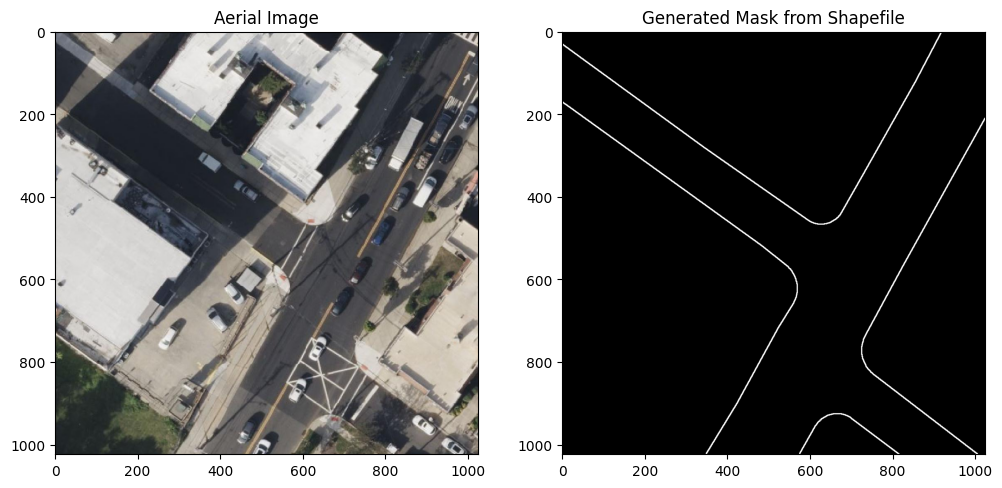

In [ ]:
# Define a robust augmentation pipeline
train_transform = A.Compose([
    # A.RandomCrop(width=512, height=512),   # Random crop to 512x512
    A.Rotate(limit=35, p=0.5),             # Randomly rotate +/- 35 degrees
    A.HorizontalFlip(p=0.5),               # Flip left/right
    A.VerticalFlip(p=0.5),                 # Flip up/down
    A.RandomBrightnessContrast(p=0.2),     # Change lighting slightly
    # A.GaussNoise(p=0.2),                 # Add grain/noise
])

# Initialize Dataset
dataset = CurbDataset(
    csv_path=csv_path,
    images_dir=images_dir,
    shapefile_path=shapefile_path,
    pixels_per_unit=4,  # Keep your setting (4 px = 1 ft)
    img_size=1024,       # Keep your setting
    transform=train_transform
)

# Get the first image
image_tensor, mask_tensor = dataset[0]

# Convert back to numpy for plotting
img_display = image_tensor.numpy().transpose(1, 2, 0)
mask_display = mask_tensor.numpy().squeeze()

# Plot them side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_display)
ax[0].set_title("Aerial Image")
ax[1].imshow(mask_display, cmap='gray')
ax[1].set_title("Generated Mask from Shapefile")
plt.show()

In [ ]:
# Define Loss Class
# I am using a custom combined loss to force the model to learn geometry and lines
class CurbLoss(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # Dice: Good for geometry/shape
        self.dice = smp.losses.DiceLoss(mode='binary', from_logits=True)
        # BCE: Good for pixel accuracy (forces the model to find the line)
        self.bce = smp.losses.SoftBCEWithLogitsLoss()

    def forward(self, logits, targets):
        # We assume model outputs "logits" (no sigmoid applied yet)
        return 0.5 * self.dice(logits, targets) + 0.5 * self.bce(logits, targets)

In [ ]:
# Define Encoder
# We use ResNet34 because it is fast and should work well with small data
ENCODER = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'
CLASSES = 1  # Curb only
ACTIVATION = 'sigmoid' # Output probability 0 to 1

# Define models and create a dictionary for them
# We are going to create a loop to train them one by one
models_dict = {

    # Option 1 (Best for geometry/lines)
    'U-Net': smp.Unet(
        encoder_name=ENCODER,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=3,
        classes=CLASSES,
        activation=None
    ),

    # Option 2 (Good for real-time/large maps)
    'LinkNet': smp.Linknet(
        encoder_name=ENCODER,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=3,
        classes=CLASSES,
        activation=None
    ),

    # Option 3(Good if curbs are different sizes)
    'FPN': smp.FPN(
        encoder_name=ENCODER,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=3,
        classes=CLASSES,
        activation=None
    ),

    # Option 4 (Good for blobs, risky for thin lines)
    'DeepLabV3+': smp.DeepLabV3Plus(
        encoder_name=ENCODER,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=3,
        classes=CLASSES,
        activation=None
    )
}


# Check if it runs on GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"We are using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print("We are using CPU...")

We are using GPU: NVIDIA GeForce RTX 4070 Laptop GPU


In [ ]:
# Define batch size, learning rate and number of epochs
BATCH_SIZE = 4        # Try 2 or 1 if you get "Out of Memory" errors
LR = 0.0001           # Learning Rate (how fast it learns)
EPOCHS = 50          # How many times to go through the dataset

######################
# Data Loaders
######################
# 80% for training and 20% for validation
train_size = int(0.8 * len(dataset))
valid_size = len(dataset) - train_size
train_dataset, valid_dataset = torch.utils.data.random_split(dataset, [train_size, valid_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)  #drop_last=True for deeplabv3+
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

######################
# Create function to run all the models
######################

def train_and_evaluate(name, model, epochs=20):
    print(f"Lets start the Training...{name}")
    #use GPU if available
    model.to(device)

    #define optimizer and loss
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    loss_fn = CurbLoss()

    best_loss = float('inf')

    #loop thru the epochs
    for epoch in range(epochs):
        #train mode
        model.train()
        #initial loss
        total_loss = 0

        for images, masks in train_loader:
            # Move data to GPU
            images, masks = images.to(device), masks.to(device)

            # Forward Pass (Predict)
            optimizer.zero_grad()
            preds = model(images)

            # Calculate Loss (Compare Prediction vs Real Mask)
            loss = loss_fn(preds, masks)

            # Backward Pass (Update Weights)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        # print loss for each epoch so we can keep tracking
        print(f"Epoch [{epoch+1}/{EPOCHS}]  |  Train Loss: {avg_loss:.4f}")

    #save best model
    torch.save(model.state_dict(), 'best_curb_model.pth')
    print("Training Complete! Model saved as 'best_curb_model.pth'")

    print(f"{name} done with training.\n")
    return model

In [ ]:
trained_models = {}

# Looping through all 4 models
for name, model_instance in models_dict.items():
    trained_models[name] = train_and_evaluate(name, model_instance, epochs=EPOCHS)

Lets start the Training...U-Net
Epoch [1/50]  |  Train Loss: 0.7421
Epoch [2/50]  |  Train Loss: 0.6965
Epoch [3/50]  |  Train Loss: 0.6591
Epoch [4/50]  |  Train Loss: 0.6322
Epoch [5/50]  |  Train Loss: 0.6136
Epoch [6/50]  |  Train Loss: 0.5979
Epoch [7/50]  |  Train Loss: 0.5872
Epoch [8/50]  |  Train Loss: 0.5789
Epoch [9/50]  |  Train Loss: 0.5714
Epoch [10/50]  |  Train Loss: 0.5641
Epoch [11/50]  |  Train Loss: 0.5570
Epoch [12/50]  |  Train Loss: 0.5506
Epoch [13/50]  |  Train Loss: 0.5435
Epoch [14/50]  |  Train Loss: 0.5370
Epoch [15/50]  |  Train Loss: 0.5273
Epoch [16/50]  |  Train Loss: 0.5185
Epoch [17/50]  |  Train Loss: 0.5099
Epoch [18/50]  |  Train Loss: 0.5017
Epoch [19/50]  |  Train Loss: 0.4958
Epoch [20/50]  |  Train Loss: 0.4858
Epoch [21/50]  |  Train Loss: 0.4791
Epoch [22/50]  |  Train Loss: 0.4707
Epoch [23/50]  |  Train Loss: 0.4663
Epoch [24/50]  |  Train Loss: 0.4592
Epoch [25/50]  |  Train Loss: 0.4579
Epoch [26/50]  |  Train Loss: 0.4467
Epoch [27/50]  

Prepare images from each model to compare final result...


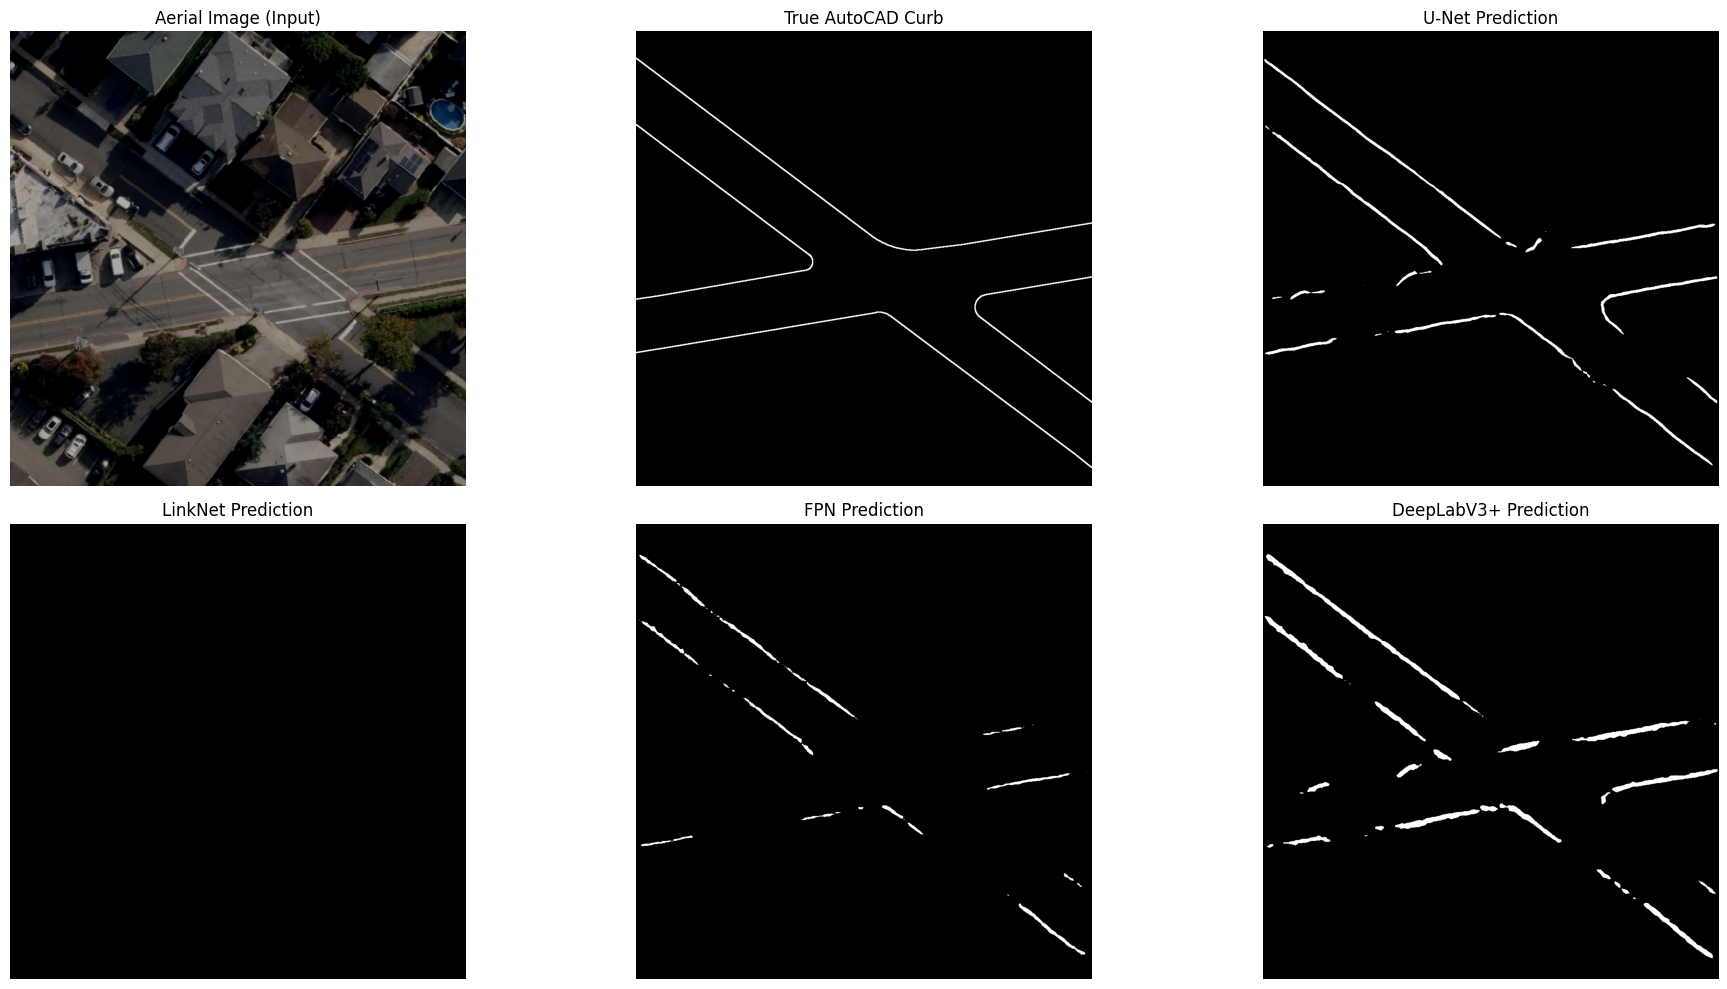

In [ ]:
print("Prepare images from each model to compare final result...")

# Grab one batch of validation data
images, masks = next(iter(valid_loader))
images = images.to(device)

plt.figure(figsize=(20, 10))

# Plotting the Original Image & True Mask first
plt.subplot(2, 3, 1)
plt.imshow(images[0].cpu().permute(1, 2, 0))
plt.title("Aerial Image (Input)")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(masks[0].cpu().squeeze(), cmap='gray')
plt.title("True AutoCAD Curb")
plt.axis('off')

# Now plotting predictions for each model
plot_idx = 3
results_table = []

for name, model in trained_models.items():
    model.eval()
    with torch.no_grad():
        pred_logits = model(images)
        pred_mask = (pred_logits.sigmoid() > 0.5).float() # Thresholding

        # Calculate IoU for the table
        intersection = (pred_mask * masks.to(device)).sum()
        union = pred_mask.sum() + masks.to(device).sum() - intersection
        iou = (intersection + 1e-6) / (union + 1e-6)
        results_table.append({'Model': name, 'IoU Score': iou.item()})

        # Add to plot
        if plot_idx <= 6: # Only plotting first 4 to fit grid
            plt.subplot(2, 3, plot_idx)
            plt.imshow(pred_mask[0].cpu().squeeze(), cmap='gray')
            plt.title(f"{name} Prediction")
            plt.axis('off')
            plot_idx += 1

plt.tight_layout()
plt.show()

In [ ]:
print("Comparison Table:")
results_df = pd.DataFrame(results_table)
print(results_df.sort_values(by='IoU Score', ascending=False))

Comparison Table:
        Model     IoU Score
0       U-Net  2.953539e-01
3  DeepLabV3+  2.280156e-01
2         FPN  2.224582e-01
1     LinkNet  1.882814e-11
